# Задание Pro — вариант на PyTorch

Используется база вин `load_wine()` из `sklearn.datasets`.

Сохранена логика исходного файла:

- загрузка данных;
- разделение на обучающую, валидационную и тестовую выборки;
- стандартизация признаков только по обучающей выборке;
- обучение нейронной сети;
- вывод ошибки и точности;
- построение графиков;
- вывод количества параметров модели.


In [1]:

import numpy as np

# Графики
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

%matplotlib inline


In [2]:
# Фиксируем случайность
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Ограничиваем число потоков
torch.set_num_threads(1)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Устройство:', device)


Устройство: cpu


In [3]:
class WineNet(nn.Module):
    def __init__(self, use_bn=False):
        super().__init__()

        if use_bn:
            self.net = nn.Sequential(
                nn.Linear(13, 64),
                nn.BatchNorm1d(64),
                nn.ReLU(),

                nn.Linear(64, 32),
                nn.BatchNorm1d(32),
                nn.ReLU(),

                nn.Linear(32, 3)
            )
        else:
            self.net = nn.Sequential(
                nn.Linear(13, 64),
                nn.ReLU(),

                nn.Linear(64, 32),
                nn.ReLU(),

                nn.Linear(32, 3)
            )

    def forward(self, x):
        return self.net(x)


In [4]:
class Wine_classific:
    def __init__(self, epochs=64, batch_size=8, use_bn=False, learning_rate=0.001, patience=10):
        self.epochs = epochs
        self.batch_size = batch_size
        self.use_bn = use_bn
        self.learning_rate = learning_rate
        self.patience = patience
        self.scaler = StandardScaler()
        self.model = None

    def load_data(self):
        # Загружаем данные
        wine = load_wine()
        x_data = wine['data'].astype('float32')
        y_data = wine['target'].astype('int64')


        # 60% обучение, 20% валидация, 20% тест
        x_train_val, x_test, y_train_val, y_test = train_test_split(
            x_data,
            y_data,
            test_size=0.2,
            random_state=42,
            stratify=y_data
        )

        x_train, x_val, y_train, y_val = train_test_split(
            x_train_val,
            y_train_val,
            test_size=0.25,   # 0.25 от 0.8 = 0.2 от всего набора
            random_state=42,
            stratify=y_train_val
        )

        # Стандартизация только по обучающей выборке
        x_train = self.scaler.fit_transform(x_train).astype('float32')
        x_val = self.scaler.transform(x_val).astype('float32')
        x_test = self.scaler.transform(x_test).astype('float32')

        return x_train, y_train, x_val, y_val, x_test, y_test

    def create_model(self):
        self.model = WineNet(use_bn=self.use_bn).to(device)
        return self.model

    def make_loader(self, x, y, shuffle=False):
        x_tensor = torch.tensor(x, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.long)
        dataset = TensorDataset(x_tensor, y_tensor)
        return DataLoader(dataset, batch_size=self.batch_size, shuffle=shuffle)

    def run_epoch(self, loader, criterion, optimizer=None):
        # Условие если optimizer передан — обучение, если нет — проверка
        is_train = optimizer is not None

        if is_train:
            self.model.train()
        else:
            self.model.eval()

        total_loss = 0
        total_correct = 0
        total_count = 0

        with torch.set_grad_enabled(is_train):
            for x_batch, y_batch in loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)

                if is_train:
                    optimizer.zero_grad()

                outputs = self.model(x_batch)
                loss = criterion(outputs, y_batch)

                if is_train:
                    loss.backward()
                    optimizer.step()

                predictions = torch.argmax(outputs, dim=1)
                total_correct += (predictions == y_batch).sum().item()
                total_loss += loss.item() * x_batch.size(0)
                total_count += x_batch.size(0)

        avg_loss = total_loss / total_count
        avg_accuracy = total_correct / total_count
        return avg_loss, avg_accuracy

    def train_model(self):
        x_train, y_train, x_val, y_val, x_test, y_test = self.load_data()

        train_loader = self.make_loader(x_train, y_train, shuffle=True)
        val_loader = self.make_loader(x_val, y_val, shuffle=False)
        test_loader = self.make_loader(x_test, y_test, shuffle=False)

        model = self.create_model()
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=self.learning_rate)

        history = {
            'loss': [],
            'accuracy': [],
            'val_loss': [],
            'val_accuracy': []
        }

        best_val_loss = float('inf')
        best_state = None
        bad_epochs = 0

        for epoch in range(self.epochs):
            train_loss, train_accuracy = self.run_epoch(train_loader, criterion, optimizer)
            val_loss, val_accuracy = self.run_epoch(val_loader, criterion)

            history['loss'].append(train_loss)
            history['accuracy'].append(train_accuracy)
            history['val_loss'].append(val_loss)
            history['val_accuracy'].append(val_accuracy)

            print(
                f"Эпоха {epoch + 1:03d}/{self.epochs} | "
                f"ошибка: {train_loss:.4f} | точность: {train_accuracy:.4f} | "
                f"ошибка проверки: {val_loss:.4f} | точность проверки: {val_accuracy:.4f}"
            )

            # Ранняя остановка
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {key: value.cpu().clone() for key, value in model.state_dict().items()}
                bad_epochs = 0
            else:
                bad_epochs += 1

            if bad_epochs >= self.patience:
                print('Ранняя остановка')
                break

        # Возвращаем лучшие веса
        if best_state is not None:
            model.load_state_dict(best_state)
            model.to(device)

        test_loss, test_accuracy = self.run_epoch(test_loader, criterion)
        return history, test_loss, test_accuracy

    def plot_history(self, history):
        plt.figure(figsize=(8, 5))
        plt.plot(history['loss'], label='Ошибка на обучении')
        plt.plot(history['val_loss'], label='Ошибка на валидации')
        plt.title('График ошибки')
        plt.xlabel('Эпоха')
        plt.ylabel('Ошибка')
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(8, 5))
        plt.plot(history['accuracy'], label='Точность на обучении')
        plt.plot(history['val_accuracy'], label='Точность на валидации')
        plt.title('График точности')
        plt.xlabel('Эпоха')
        plt.ylabel('Точность')
        plt.legend()
        plt.grid(True)
        plt.show()

    def summary(self):

        if self.model is None:
            self.create_model()

        print(self.model)

        total_params = sum(p.numel() for p in self.model.parameters())
        trainable_params = sum(p.numel() for p in self.model.parameters() if p.requires_grad)

        print('\nВсего параметров:', total_params)
        print('Обучаемых параметров:', trainable_params)
        print('Необучаемых параметров:', total_params - trainable_params)


Эпоха 001/64 | ошибка: 1.0640 | точность: 0.4811 | ошибка проверки: 0.9958 | точность проверки: 0.9167
Эпоха 002/64 | ошибка: 0.7880 | точность: 0.8774 | ошибка проверки: 0.8185 | точность проверки: 1.0000
Эпоха 003/64 | ошибка: 0.6463 | точность: 0.9057 | ошибка проверки: 0.6274 | точность проверки: 1.0000
Эпоха 004/64 | ошибка: 0.5179 | точность: 0.9528 | ошибка проверки: 0.4872 | точность проверки: 0.9722
Эпоха 005/64 | ошибка: 0.4138 | точность: 0.9811 | ошибка проверки: 0.3972 | точность проверки: 0.9722
Эпоха 006/64 | ошибка: 0.4323 | точность: 0.9340 | ошибка проверки: 0.3299 | точность проверки: 0.9722
Эпоха 007/64 | ошибка: 0.3693 | точность: 0.9434 | ошибка проверки: 0.2972 | точность проверки: 0.9722
Эпоха 008/64 | ошибка: 0.2884 | точность: 0.9906 | ошибка проверки: 0.2803 | точность проверки: 0.9722
Эпоха 009/64 | ошибка: 0.2823 | точность: 0.9906 | ошибка проверки: 0.2594 | точность проверки: 0.9722
Эпоха 010/64 | ошибка: 0.2493 | точность: 1.0000 | ошибка проверки: 0.237

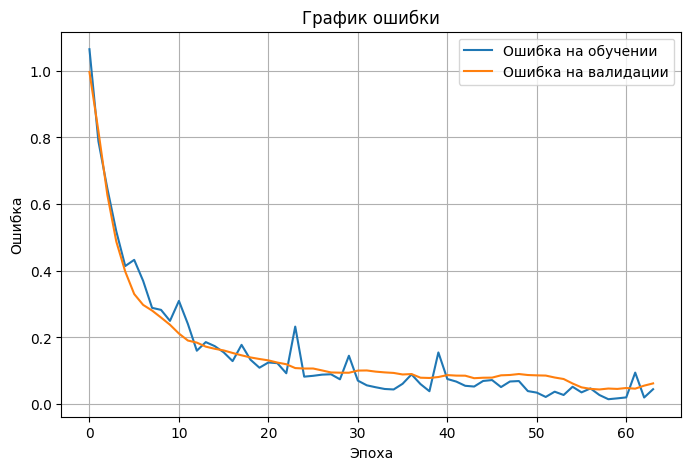

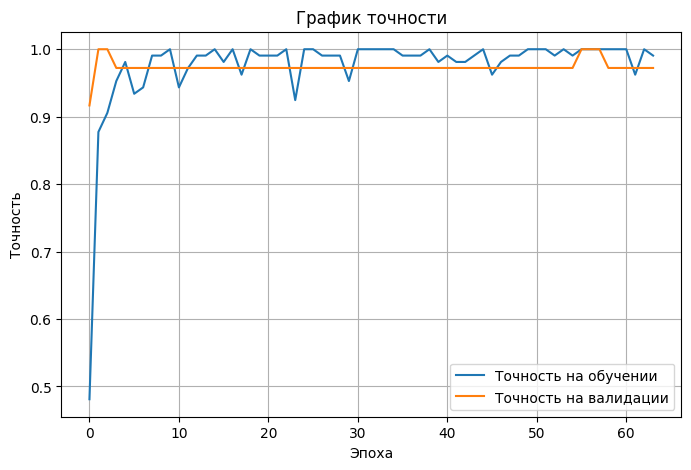

WineNet(
  (net): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=3, bias=True)
  )
)

Всего параметров: 3267
Обучаемых параметров: 3267
Необучаемых параметров: 0


In [5]:
m1 = Wine_classific(
    epochs=64,
    batch_size=16,
    use_bn=True,
    learning_rate=0.001,
    patience=10
)

history, loss, accuracy = m1.train_model()

print('\nОшибка на тестовой выборке:', loss)
print('Точность на тестовой выборке:', accuracy)

m1.plot_history(history)
m1.summary()


In [6]:

torch.save(m1.model.state_dict(), 'wine_model_pytorch.pth')
print('Модель сохранена в файл wine_model_pytorch.pth')


Модель сохранена в файл wine_model_pytorch.pth
